In [1]:
# Downloading the needed libraries
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time
from diffrax import *

# Importing the other codes we need
from controls import *
from hybrid_joint import *

Quadratic rough Heston model - RDE version

$$ \begin{cases}\mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \\ \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t \end{cases} $$

with $\theta$ some function chosen to match the VIX futures? Check this is the same as solving $V$ first and then taking the exponential martingale.

$$S_t = \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$


In [2]:
class RDE_QuadHeston:
    
    def __init__(self, grid_points, epsilon, M, T, H):
        """
        grid_points: number of points in the simulation grid
        epsilon: time step?
        H: Hurst parameter
        M: number of paths to simulate
        T: time horizon
        """
        self.epsilon = epsilon
        self.grid_points = grid_points
        self.M, self.T, self.H = M, T, H
        # kappa parameter for the Hybrid scheme
        self.kappa = 1
        
        # create the time grid (over the time horizon 1)
        self.times = jnp.arange(0., 1., self.epsilon)
        # every point x in the grid is approximated with the closest lower integer to x*eps
        # needed for the subsampling
        self.every_nth_pt = int(self.grid_points*self.epsilon)
        # smaller time step
        self.solver_epsilon = 0.01*self.epsilon
        # lag (it has to be slightly bigger than the time step)
        self.lag = 1.2*self.epsilon


    def run__init__(self):
        # generating fractional Bm paths and Bm paths via hybrid scheme
        self.fBmpath, self.Bmpath = hybrid_scheme(self.grid_points, self.M, self.T, self.H, self.kappa)

        # Create the Bm controls
        # Subsampling the Bm paths
        self.subsampled_Bmpath = self.Bmpath[:, ::self.every_nth_pt]
        # Interpolating the subsampled Bm paths
        self.bm_interp = LinearInterpolation(self.times, self.subsampled_Bmpath[0,:])
        self.bm_interp = evaluate_and_reshape(self.bm_interp.evaluate)

        # Create the fbm control
        # Subsampling the fBm paths
        self.subsampled_fBmpath = self.fBmpath[:, ::self.every_nth_pt]
        # Interpolating the subsampled fBm paths
        self.fbm_interp = LinearInterpolation(self.times, self.subsampled_fBmpath[0,:])
        self.fbm_interp = evaluate_and_reshape(self.fbm_interp.evaluate)

        # lagged fBm increments
        self.lagged_fbm_control = lagged_control(lambda t: self.fbm_interp(0,t), self.lag)
        # concatenation of lagged fBm and Bm
        self.lead_lag_control = join_controls(self.lagged_fbm_control, self.bm_interp)

    # precomputing FBm and Bm paths
    def precompute_paths(self, nb_montecarlo):
        """
        nb_montecarlo: number of Montecarlo simulations
        """
        self.lagged_fbm_control_vec, self.bm_interp_vec = [], []
        
        for _ in range(nb_montecarlo):
            self.run__init__()
            self.bm_interp_vec.append(self.bm_interp)
            self.lagged_fbm_control_vec.append(self.lagged_fbm_control)

    
    def callPrice_RDE_QuadHeston_MC(self, params, payoff_function, printYN = False):
        """
        params: parameters
        payoff_function: Payoff function for which we want to compute prices under quadRHeston
        """
        self.prices, self.finalS = [], []
        counter = 0
        
        # for-cycle over the trajectories (i.e. for each traj in our MOntecarlo)
        for (bm_interp, lagged_fbm_control) in zip(self.lagged_fbm_control_vec, self.bm_interp_vec):
            # update couter for the for-cycle
            counter += 1
            # compute integral price and expo martingale for the traj
            integral_price, exp_martingale = self.run_paths_RDE_QuadHeston(params, bm_interp, lagged_fbm_control)
            # add the final value of the exponential martingale (i.e. S_T) to the list 
            # where we store all the different values for the different trajectories
            self.finalS.append(exp_martingale[-1])
            # do the same for the pricing function
            self.prices.append(payoff_function(self.finalS[-1]))
            if printYN:
                print(counter, "|", nb_montecarlo, " || ", "Price: ", self.prices[-1], "ST = ", self.finalS[-1])
    
    # drift of the quadratic rough Heston model       
    def drift_qrh_vol(self, t, y, args): 
        """
        t, y, args
        """
        return jnp.array([lam*(theta - y[1])]) 
    
    # volatility/diffusion of the quadratic rough Heston model 
    def diffusion_qrh_vol(self, t, y, args):
        """
        t, y, args    
        """
        return jnp.array([ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c )])
        
    def run_paths_RDE_QuadHeston(self, params, bm_interp, lagged_fbm_control):
        """
        params, bm_interp, lagged_fbm_control 
        """
        a, b, c, theta, lam, eta = params

        y0 = jnp.array([1])
        saveat = SaveAt(ts = self.times)
        
        terms = MultiTerm(ODETerm(self.drift_qrh_vol), ControlTerm(self.diffusion_qrh_vol, lagged_fbm_control))
        solution_vol = diffeqsolve(terms, Euler(), 0, 1, dt0 = self.solver_epsilon, max_steps=None, y0=y0, saveat=saveat)
        
        Z = LinearInterpolation(self.times, solution_vol.ys[:,0]).evaluate #create the vol process
        
        y0 = jnp.array([0,0])
        
        drift_qrh_price = lambda t, y, args: jnp.array([-(1/2) * ( a * jnp.square(Z(t) - b) + c ), 0])
        diffusion_qrh_price = lambda t, y, args: jnp.array([[jnp.sqrt(a * jnp.square(Z(t) - b) + c)],[1]])
        terms = MultiTerm(ODETerm(drift_qrh_price), ControlTerm(diffusion_qrh_price, bm_interp))
        integral_price = diffeqsolve(terms, Euler(), 0, 1, dt0 = self.epsilon, max_steps=None, y0=y0, saveat=saveat) # note solver has to have size epsilon for this to be Ito
        exp_martingale = jnp.exp(integral_price.ys[:,0])
        
        return integral_price, exp_martingale


## Numerical tests

In [3]:
H, kappa, M = 0.1, 1, 1
grid_points = 1000
T = 1.
# Model parameters
a, b, c, theta, lam, eta = 1., 0.5, 1., 2., 0.2, 0.4
params = a, b, c, theta, lam, eta

epsilon = 0.01

### One-path example

In [4]:
nb_montecarlo = 1

rde = RDE_QuadHeston(grid_points, epsilon, M, T, H)
rde.run__init__()

#############################
t0 = time.time()
rde.precompute_paths(nb_montecarlo)
precomp_time = time.time() - t0
print("Brownian path pre-computation time: ", precomp_time)
#############################

#############################
t0 = time.time()
rde.run_paths_RDE_QuadHeston(params, rde.bm_interp_vec[-1], rde.lagged_fbm_control_vec[-1])
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

Brownian path pre-computation time:  0.0004391670227050781
SDE simulation computation time:  0.5116763114929199


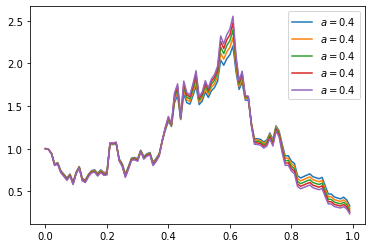

In [5]:
for a in np.linspace(.3, 1.5, 5):
    params = a, b, c, theta, lam, eta
    integral_price, exp_martingale = rde.run_paths_RDE_QuadHeston(params, rde.bm_interp_vec[-1], rde.lagged_fbm_control_vec[-1])
    plt.plot(integral_price.ts[:], exp_martingale[:], label=r'$a=$%.1f' %eta)
plt.legend(loc="best")
plt.show()

## Run Monte Carlo computations for option prices

In [6]:
a, b, c, theta, lam, eta = 1., 0.5, 1., 2., 0.2, 0.4
params = a, b, c, theta, lam, eta
nb_montecarlo = 100

In [7]:
#############################
rde = RDE_QuadHeston(grid_points, epsilon, M, T, H)
rde.run__init__()

t0 = time.time()
rde.precompute_paths(nb_montecarlo)
precomp_time = time.time() - t0
print("Brownian path pre-computation time: ", precomp_time)
#############################

Brownian path pre-computation time:  0.036035776138305664


In [8]:
strike = 2.

#############################
t0 = time.time()
rde.callPrice_RDE_QuadHeston_MC(params, lambda s: np.maximum(s-strike, 0.), printYN = False)
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

SDE simulation computation time:  44.795992851257324


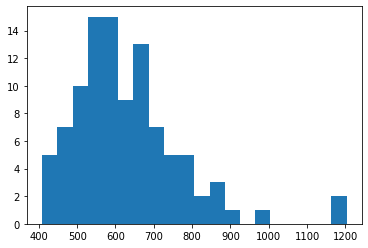

In [9]:
n_bins = len(rde.finalS) // 5
plt.hist(rde.finalS, bins=n_bins)
plt.show()